# Second Serve — Demand Prediction

Analyzes which areas and time windows have the highest food demand.  
Helps proactively notify donors when to list surplus food.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import joblib
import os
import warnings

warnings.filterwarnings('ignore')

os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("Libraries loaded")

Libraries loaded


## 1. Simulate Demand Data

Each row = one food redistribution event.  
Demand patterns are based on time of day, area density, and food type.

In [2]:
np.random.seed(42)
n = 2000

hours = np.random.randint(0, 24, n)
areas = np.random.choice(['Mumbai_North', 'Mumbai_South', 'Pune_Central', 'Pune_Outer'], n)
food_types = np.random.choice(['veg', 'non-veg', 'vegan'], n, p=[0.6, 0.3, 0.1])
quantities = np.random.randint(1, 50, n)

print("Simulated", n, "demand events")
print("Areas:", np.unique(areas))
print("Food types:", np.unique(food_types))

Simulated 2000 demand events
Areas: ['Mumbai_North' 'Mumbai_South' 'Pune_Central' 'Pune_Outer']
Food types: ['non-veg' 'veg' 'vegan']


## 2. Label Demand Level

Demand is high during meal times (7–9 AM, 12–2 PM, 7–9 PM) and in dense areas.

In [3]:
def compute_demand(hour, area, quantity):
    score = 0

    # Meal time windows
    if hour in range(7, 10) or hour in range(12, 15) or hour in range(19, 22):
        score += 2

    # Dense urban areas have higher demand
    if area in ['Mumbai_South', 'Pune_Central']:
        score += 1

    # Larger quantities attract more demand
    if quantity > 20:
        score += 1

    if score >= 3:
        return 'high'
    elif score >= 1:
        return 'medium'
    else:
        return 'low'


demand_labels = [compute_demand(h, a, q) for h, a, q in zip(hours, areas, quantities)]

demand_df = pd.DataFrame({
    'hour': hours,
    'area': areas,
    'food_type': food_types,
    'quantity': quantities,
    'demand': demand_labels
})

print(demand_df.shape)
print("\nDemand distribution:")
print(demand_df['demand'].value_counts())

demand_df.head()

(2000, 5)

Demand distribution:
demand
medium    1146
high       579
low        275
Name: count, dtype: int64


,hour,area,food_type,quantity,demand
0,6,Mumbai_South,vegan,15,medium
1,19,Pune_Outer,non-veg,7,medium
2,14,Pune_Outer,veg,29,high
3,10,Pune_Outer,veg,47,medium
4,7,Mumbai_South,non-veg,3,high


## 3. Data Analysis

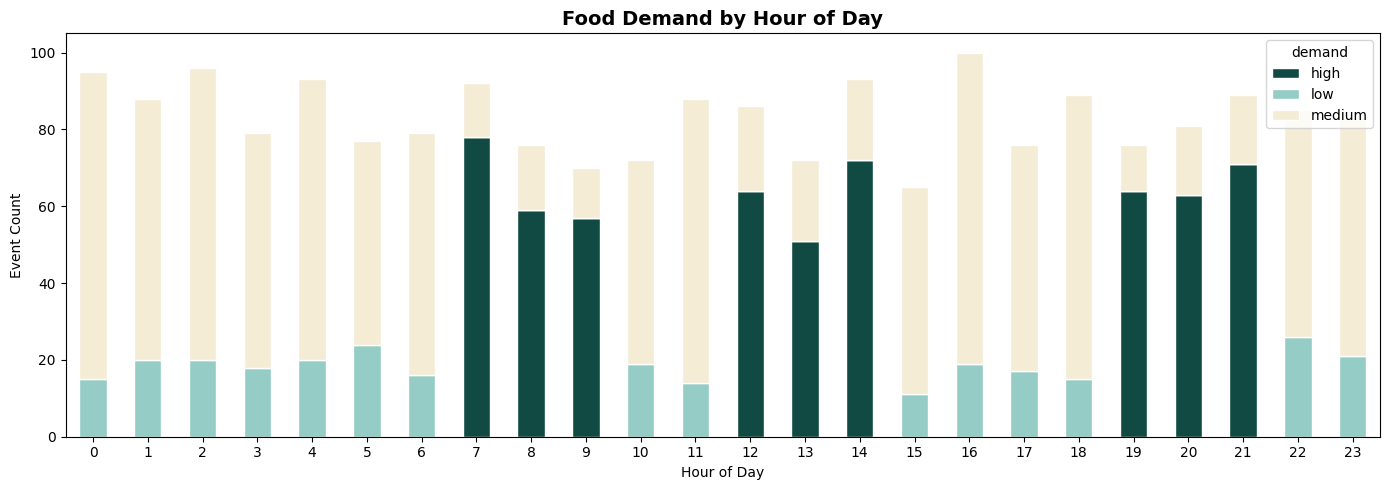

In [4]:
# Demand by hour of day
demand_by_hour = demand_df.groupby(['hour', 'demand']).size().unstack(fill_value=0)

demand_by_hour.plot(
    kind='bar',
    stacked=True,
    color=['#114a42', '#95ccc5', '#f5ecd5'],
    figsize=(14, 5),
    edgecolor='white'
)

plt.title('Food Demand by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Event Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plots/demand_by_hour.png', dpi=150)
plt.show()

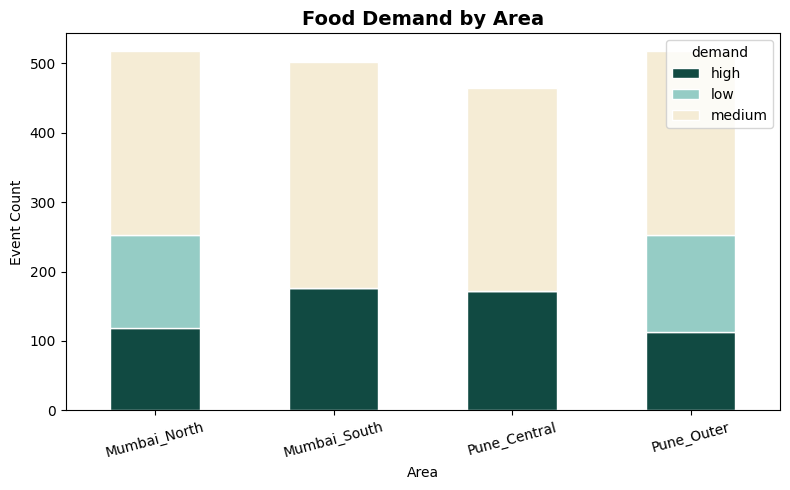

In [5]:
# Demand by area
demand_by_area = demand_df.groupby(['area', 'demand']).size().unstack(fill_value=0)

demand_by_area.plot(
    kind='bar',
    stacked=True,
    color=['#114a42', '#95ccc5', '#f5ecd5'],
    figsize=(8, 5),
    edgecolor='white'
)

plt.title('Food Demand by Area', fontsize=14, fontweight='bold')
plt.xlabel('Area')
plt.ylabel('Event Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plots/demand_by_area.png', dpi=150)
plt.show()

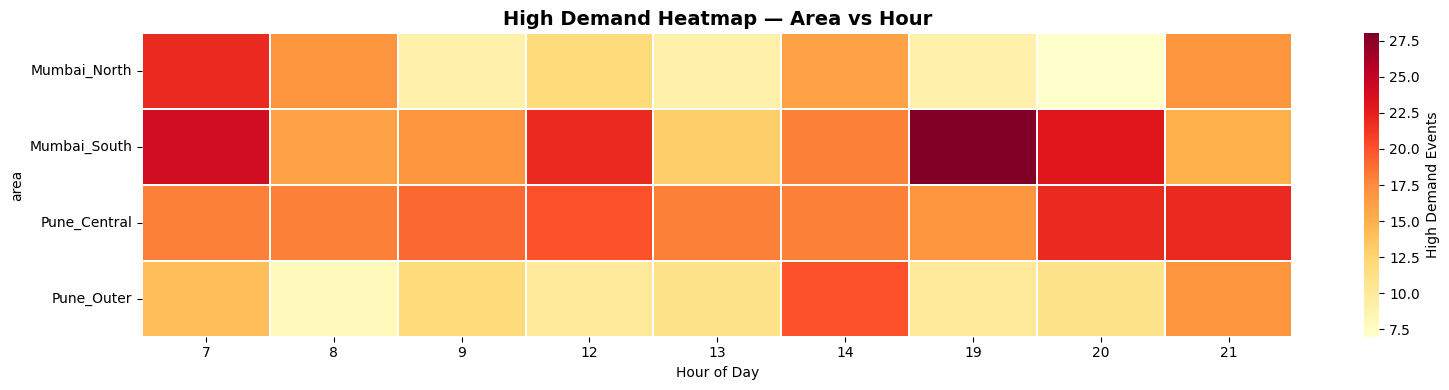

In [6]:
# Demand heatmap — hour vs area
pivot = demand_df[demand_df['demand'] == 'high'].groupby(['area', 'hour']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 4))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    linewidths=0.3,
    annot=False,
    cbar_kws={'label': 'High Demand Events'}
)

plt.title('High Demand Heatmap — Area vs Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.tight_layout()
plt.savefig('plots/demand_heatmap.png', dpi=150)
plt.show()

## 4. Encode Features

In [7]:
le_area = LabelEncoder()
le_food_type = LabelEncoder()
le_demand = LabelEncoder()

demand_df['area_enc'] = le_area.fit_transform(demand_df['area'])
demand_df['food_type_enc'] = le_food_type.fit_transform(demand_df['food_type'])
demand_df['demand_enc'] = le_demand.fit_transform(demand_df['demand'])

print("area classes:", le_area.classes_)
print("food_type classes:", le_food_type.classes_)
print("demand classes:", le_demand.classes_)

area classes: ['Mumbai_North' 'Mumbai_South' 'Pune_Central' 'Pune_Outer']
food_type classes: ['non-veg' 'veg' 'vegan']
demand classes: ['high' 'low' 'medium']


## 5. Train Demand Classifier

In [8]:
FEATURES = ['hour', 'area_enc', 'food_type_enc', 'quantity']
TARGET = 'demand_enc'

X = demand_df[FEATURES]
y = demand_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(classification_report(y_test, preds, target_names=le_demand.classes_))

              precision    recall  f1-score   support

        high       1.00      1.00      1.00       128
         low       1.00      1.00      1.00        51
      medium       1.00      1.00      1.00       221

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## 6. Feature Importance

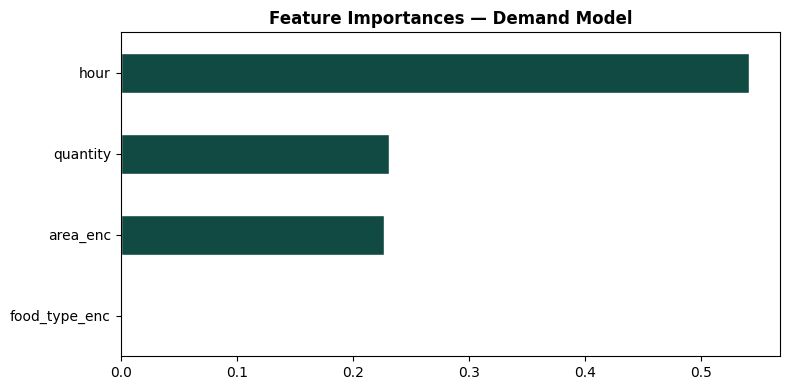

In [9]:
importances = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

importances.plot(
    kind='barh',
    figsize=(8, 4),
    color='#114a42',
    edgecolor='white'
)

plt.title('Feature Importances — Demand Model', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/demand_feature_importance.png', dpi=150)
plt.show()

## 7. Save Model and Encoders

In [10]:
joblib.dump(model, 'models/demand_model.pkl')
joblib.dump(le_area, 'models/le_area.pkl')
joblib.dump(le_food_type, 'models/le_food_demand.pkl')
joblib.dump(le_demand, 'models/le_demand.pkl')

print("Demand model saved to ml_pipeline/models/")
print("Files saved:")

for f in sorted(os.listdir('models')):
    print(" ", f)

Demand model saved to ml_pipeline/models/
Files saved:
  demand_model.pkl
  food_reference.csv
  knn_receiver_tree.pkl
  le_area.pkl
  le_category.pkl
  le_demand.pkl
  le_food_demand.pkl
  le_food_type.pkl
  le_risk.pkl
  le_stage.pkl
  le_storage.pkl
  model_animal.pkl
  model_compost.pkl
  model_human.pkl
  model_stage.pkl
  receivers_reference.csv


## 8. Test Prediction

In [11]:
def predict_demand(hour, area, food_type, quantity):
    """
    Predicts demand level for a given listing.
    Returns: high / medium / low
    """
    area_enc = le_area.transform([area])[0]
    food_type_enc = le_food_type.transform([food_type])[0]

    features = np.array([[hour, area_enc, food_type_enc, quantity]])
    pred_enc = model.predict(features)[0]

    return le_demand.inverse_transform([pred_enc])[0]


# Tests
print(predict_demand(13, 'Mumbai_South', 'veg', 30))      # lunch peak dense area
print(predict_demand(3, 'Pune_Outer', 'non-veg', 5))      # off hours quiet area
print(predict_demand(8, 'Pune_Central', 'vegan', 25))     # breakfast peak
print(predict_demand(20, 'Mumbai_North', 'veg', 40))      # dinner peak large qty

print("\nDemand prediction model working correctly.")

high
low
high
high

Demand prediction model working correctly.
